# Analysis - EDA and experiment results

Everything here is read from artifacts produced by `python -m enron_synth.eda` and `python -m enron_synth.experiment` (no API calls).

In [1]:
import json, pandas as pd, warnings
warnings.filterwarnings("ignore")
from IPython.display import Image, Markdown, display
eda = json.load(open("../reports/eda_summary.json")); dup = json.load(open("../reports/dup_stats.json"))
pd.Series({k: v for k, v in eda.items() if not isinstance(v, dict)}).to_frame("value")

,value
n_emails,517401.000000
n_mailboxes,150.000000
body_words_mean,156.184271
pct_empty_body,0.086142
pct_with_forward_or_quote,0.361269
pct_reply,0.296128
pct_forward,0.069169
pct_empty_subject,0.037083
pct_multi_recipient,0.273049
pct_with_cc,0.247160


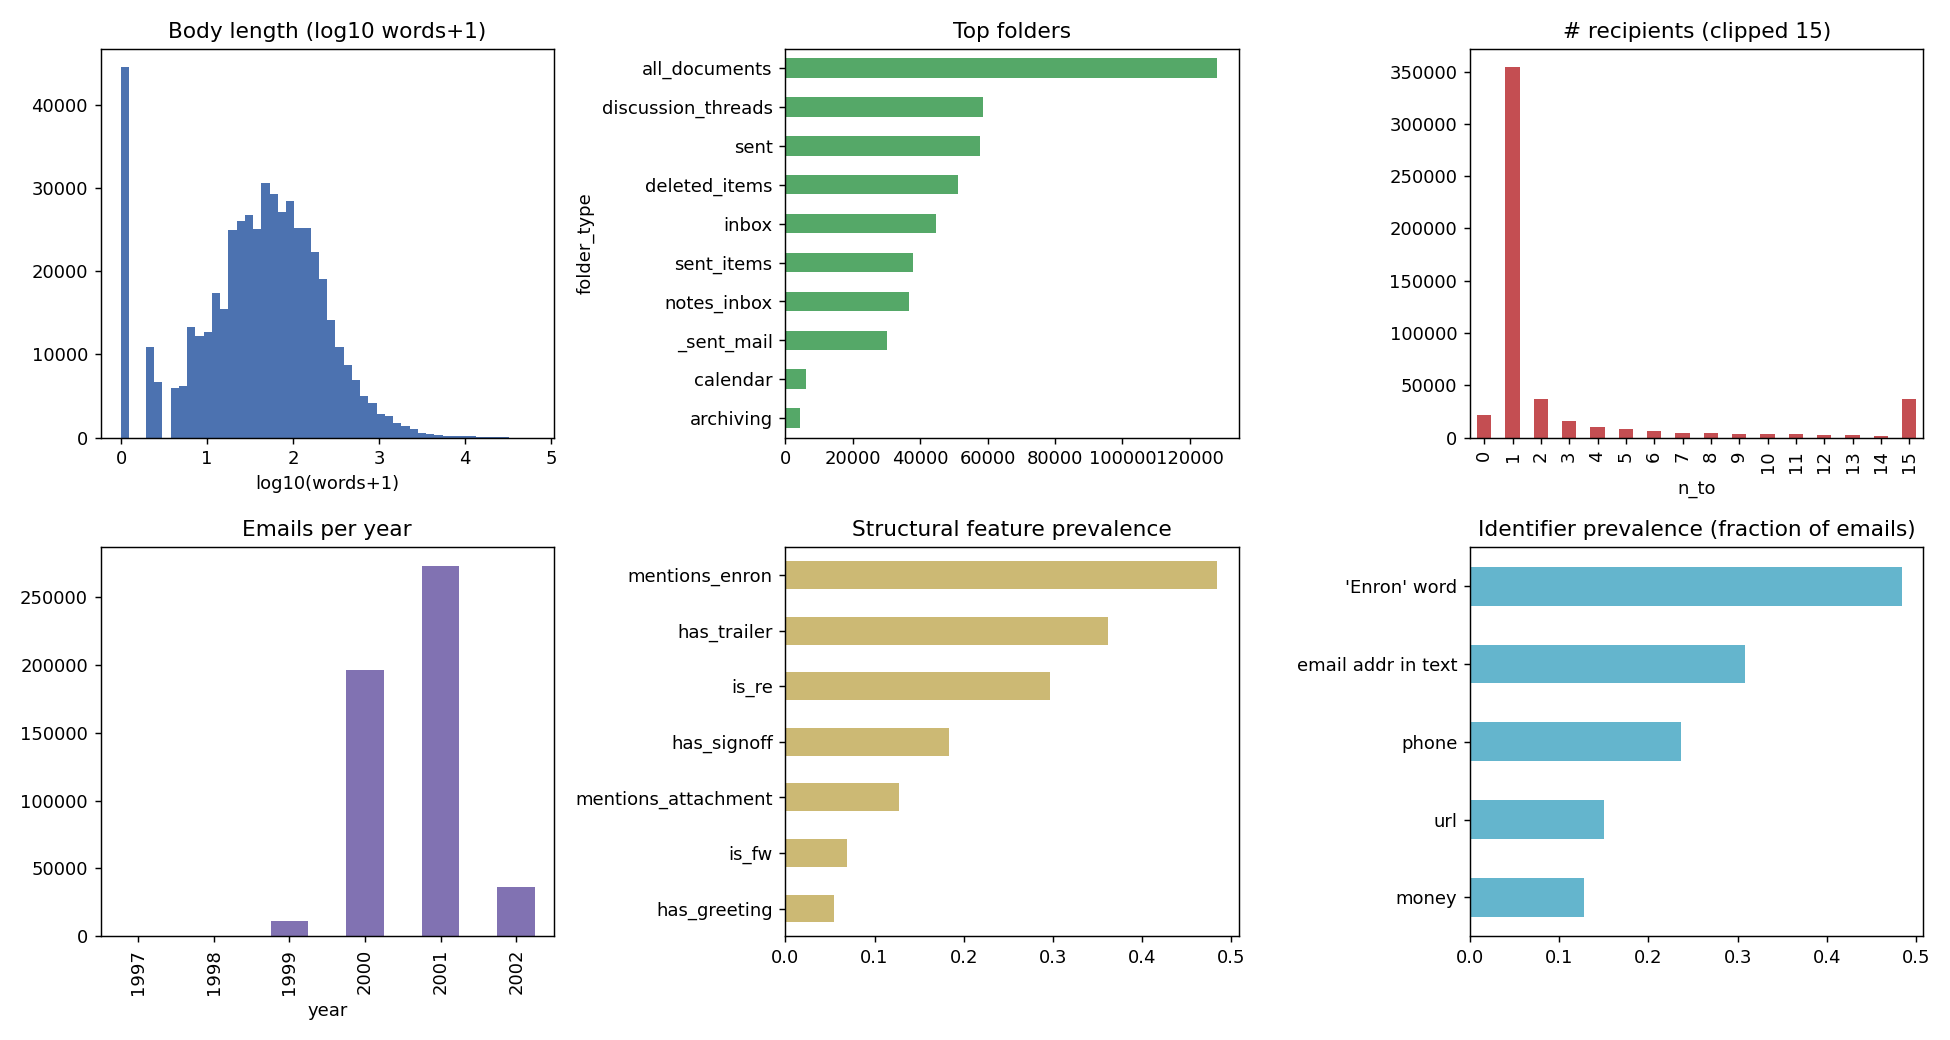

Duplicates: {'n_rows': 517401, 'n_unique_message_id': 517401, 'pct_rows_duplicate_by_message_id': 0.0, 'n_unique_body': 244773, 'pct_rows_duplicate_by_body': 0.5269181930456261, 'max_copies_of_one_message_id': 1}


In [2]:
display(Image("../reports/figures/eda_overview.png"))
print("Duplicates:", {k: v for k, v in dup.items() if k != "duplicate_rows_by_folder_top10"})

## Results (n = 120 stratified e-mails)

### Privacy & fidelity - every arm, n = 120 (offline metrics)

| Arm | n | Any leak ↓ | Global Enron-marker ↓ | Enron full-name ↓ | Forced redaction | 8-gram copy ↓ | Length ρ ↑ | Length KS ↓ | Structure agree ↑ | LLM calls/e-mail | $/e-mail |
|---|---|---|---|---|---|---|---|---|---|---|---|
| Hybrid v1 (GPT-4.1-mini) | 120 | 6.7% | 0.0% | 6.7% | 0.8% | 10.4% | 0.99 | 0.04 | 99.0% | 1.14 | $0.0012 |
| Hybrid v2 (GPT-4.1-mini) | 120 | 3.3% | 0.0% | 3.3% | 5.8% | 3.1% | 0.99 | 0.06 | 99.4% | 1.29 | $0.0012 |
| Rule-based (v2 scrub) | 120 | 12.5% | 12.5% | 0.8% | 18.3% | 53.0% | 1.00 | 0.03 | 99.8% | 0.00 | - |
| Rule-based (final scrub) | 120 | 11.7% | 11.7% | 0.0% | 10.8% | 52.1% | 1.00 | 0.03 | 99.8% | 0.00 | - |
| LLM only (naive) | 120 | 55.8% | 9.2% | 15.0% | 0.0% | 5.3% | 0.41 | 0.38 | 73.5% | 1.00 | $0.0007 |
| Hybrid v1 · Llama-3.3-70B | 120 | 3.3% | 0.0% | 3.3% | 2.5% | 29.4% | 0.96 | 0.12 | 96.5% | 1.21 | $0.0004 |
| Hybrid v1 · Qwen3-235B | 120 | 5.8% | 0.0% | 5.8% | 3.3% | 25.3% | 0.98 | 0.04 | 98.5% | 1.39 | $0.0006 |
| Hybrid v1 · Gemini-2.5-Flash | 120 | 5.8% | 0.0% | 5.8% | 5.0% | 29.6% | 0.99 | 0.05 | 98.8% | 1.24 | $0.0017 |
| Hybrid v1 · Claude Haiku 4.5 | 120 | 5.8% | 0.0% | 5.8% | 1.7% | 28.2% | 0.99 | 0.05 | 99.0% | 1.18 | $0.0043 |


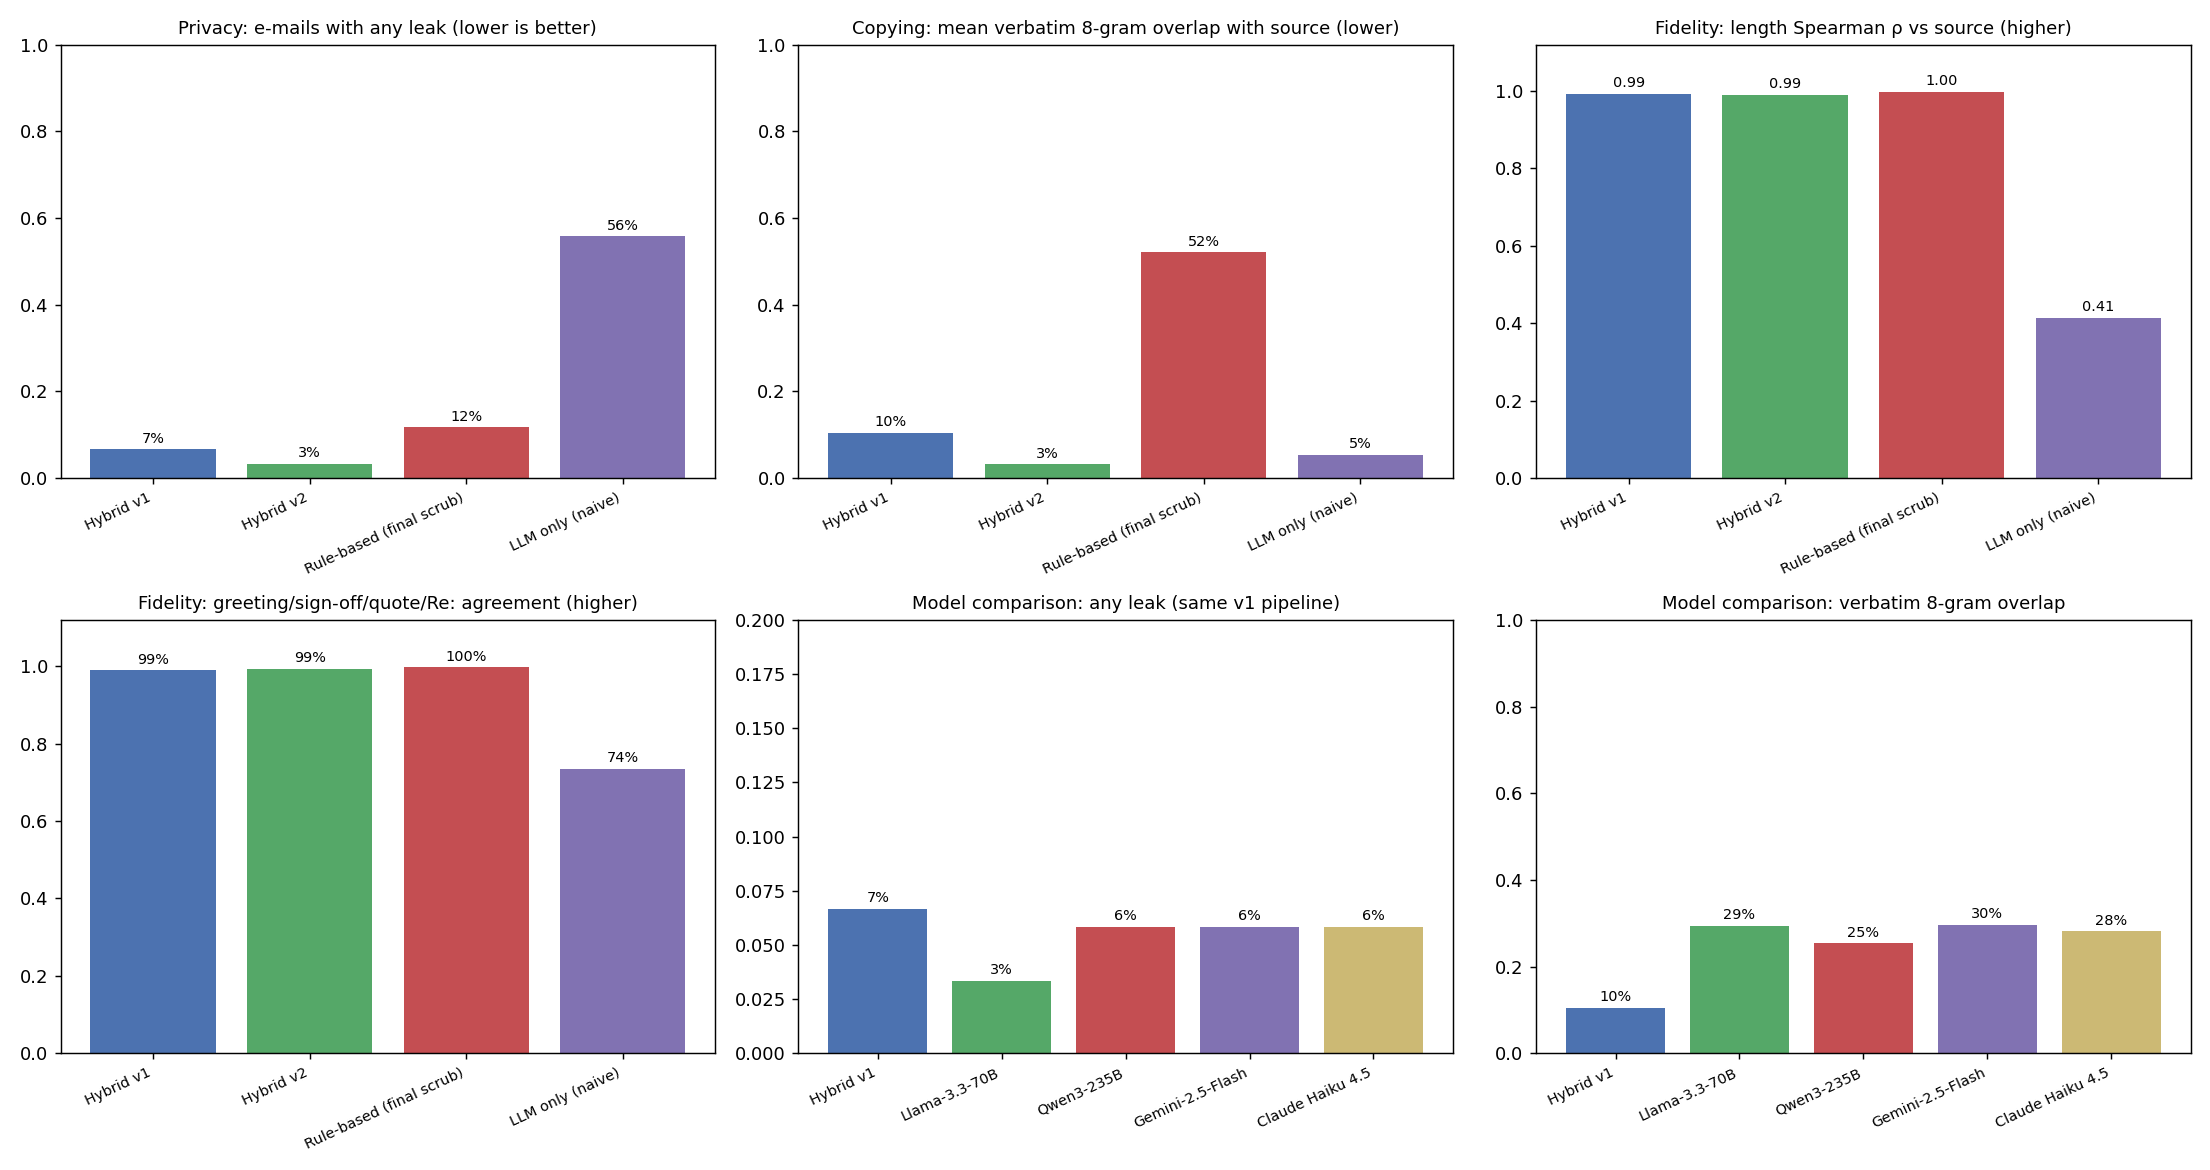

### LLM-judged realism & label preservation (v1 pipeline arms, judge = Claude Haiku 4.5)

| Arm | n | Judge score (1-5) ↑ | Real e-mail score | Judge spots the synthetic one ↓ (50% = chance) | Category κ ↑ | Intent agree ↑ | Sentiment agree ↑ | Privilege agree ↑ | Action-required agree ↑ | Sensitive agree ↑ |
|---|---|---|---|---|---|---|---|---|---|---|
| Hybrid v1 (GPT-4.1-mini) | 120 | 2.73 | 4.03 | 63.3% | 0.69 | 86.7% | 87.5% | 95.8% | 95.0% | 89.2% |
| Rule-based, final scrubber | 120 | 2.50 | 4.03 | 69.2% | 0.82 | 90.0% | 94.2% | 96.7% | 95.0% | 90.0% |
| LLM only (naive) | 120 | 1.85 | 4.03 | 83.3% | 0.80 | 86.7% | 87.5% | 95.8% | 89.2% | 86.7% |


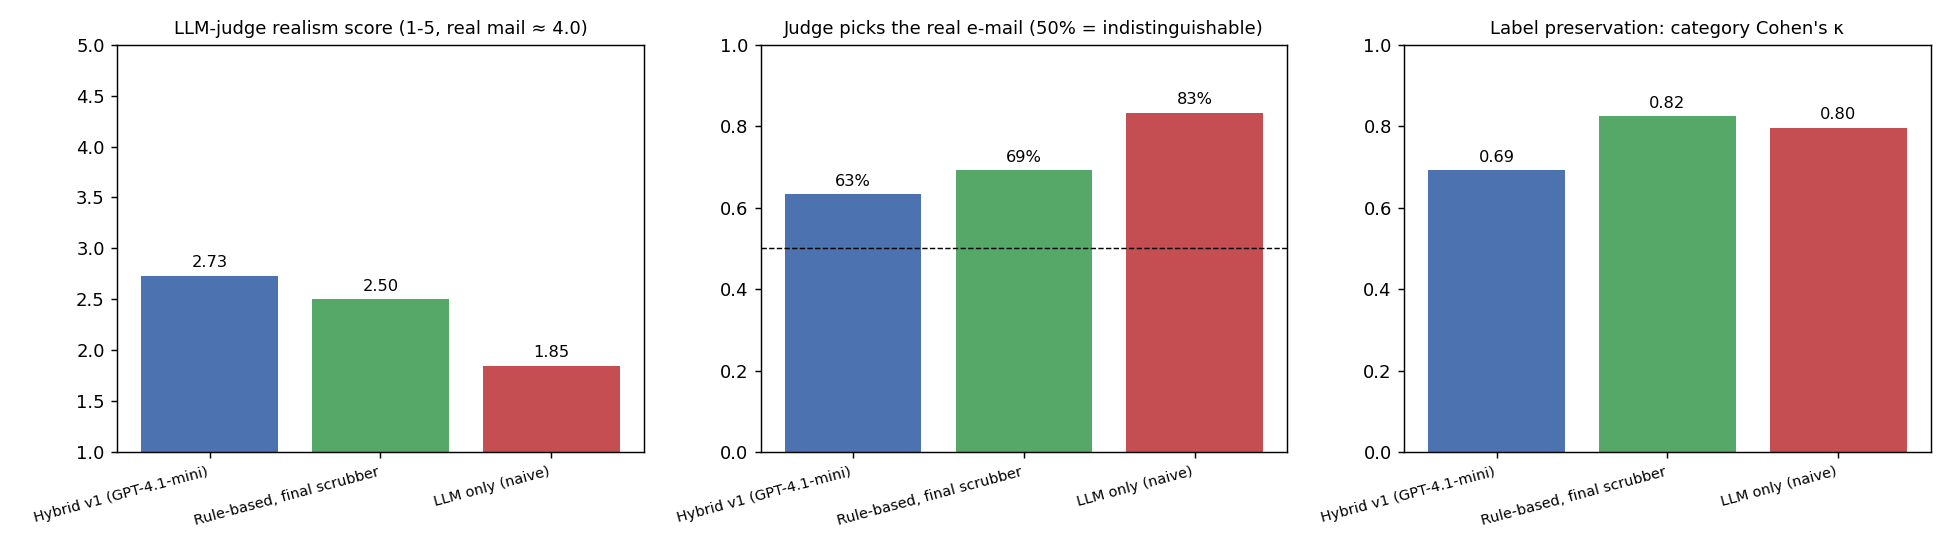

In [3]:
display(Markdown("### Privacy & fidelity - every arm, n = 120 (offline metrics)"))
display(Markdown(open("../reports/results_offline.md").read()))
display(Image("../reports/figures/results_comparison.png"))
display(Markdown("### LLM-judged realism & label preservation (v1 pipeline arms, judge = Claude Haiku 4.5)"))
display(Markdown(open("../reports/results_judged.md").read()))
display(Image("../reports/figures/results_judged.png"))

## Additional offline evaluation (no API): embeddings, real-vs-synthetic classifier, name survivors, consistency, diversity

| Arm | Embedding cos (pair / random) | Own-source top-1 / top-5 | Form-classifier AUC raw → **styled** ↓ | Source names surviving (e-mails) ↓ | Sender in sign-off | Diversity distinct-2 |
|---|---|---|---|---|---|---|
| *Original Enron (reference)* | - | - | 0.50 by definition | - | 46% | 0.765 |
| Hybrid v1 | 0.79 / 0.61 | 88% / 96% | 0.86 → **0.68** | 5.8% (46 names) | 41% | 0.801 |
| Hybrid v2 | 0.80 / 0.61 | 89% / 98% | 0.89 → **0.69** | 4.2% (21 names) | 44% | 0.807 |
| Rule-based, scrubber as of v2 | 0.90 / 0.62 | 100% / 100% | 0.77 | 5.0% (22 names) | 44% | 0.777 |
| Rule-based, final scrubber | 0.90 / 0.62 | 100% / 100% | 0.77 | 2.5% (3 names) | 41% | 0.778 |
| LLM only (naive) | 0.83 / 0.61 | 92% / 97% | 0.96 → **0.96** | 3.3% (4 names) | 0% | 0.723 |
| Llama-3.3-70B | 0.80 / 0.61 | 92% / 98% | 0.83 → **0.71** | 5.0% (44 names) | 32% | 0.742 |
| Qwen3-235B | 0.83 / 0.61 | 89% / 95% | 0.83 → **0.64** | 4.2% (44 names) | 50% | 0.811 |
| Gemini-2.5-Flash | 0.82 / 0.61 | 92% / 96% | 0.87 → **0.67** | 5.8% (46 names) | 37% | 0.787 |
| Claude Haiku 4.5 | 0.82 / 0.61 | 90% / 98% | 0.82 → **0.65** | 5.8% (46 names) | 30% | 0.786 |


{'unique_senders': 20325, 'unique_recipients': 78383, 'unique_sender_domains': 5291, 'pct_internal_only': 0.6539705180314688, 'unique_normalised_subjects': 127138, 'pct_subjects_with_>1_message': 0.6681479966650411}


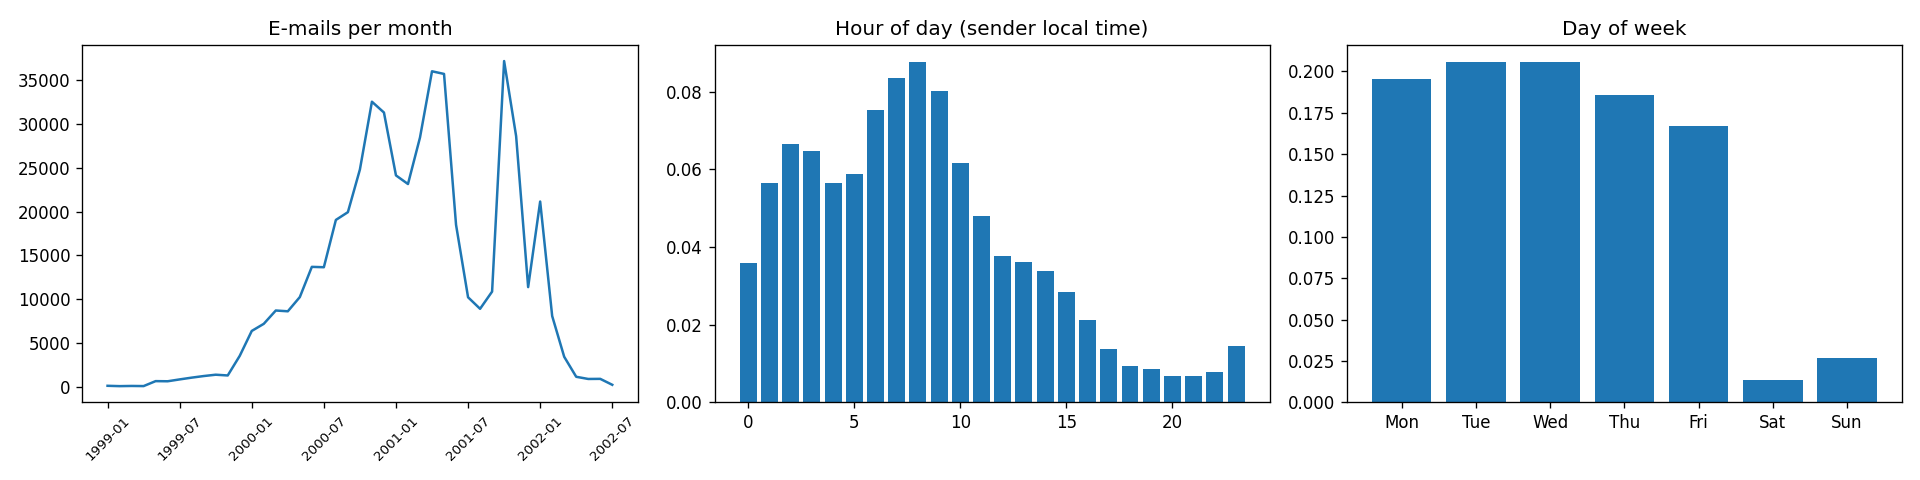

In [4]:
display(Markdown(open("../reports/results_extra.md").read()))
extra = json.load(open("../reports/eda_extra.json"))
print({k: extra[k] for k in ["unique_senders", "unique_recipients", "unique_sender_domains", "pct_internal_only", "unique_normalised_subjects", "pct_subjects_with_>1_message"]})
display(Image("../reports/figures/eda_extra.png"))

## Label preservation per field (hybrid v1, judged)

In [5]:
res = json.load(open("../reports/results_judged_v1.json"))
pd.DataFrame(res["hybrid"]["utility"]).T.round(3)

,agreement,kappa
category,0.733,0.692
intent,0.867,0.798
sentiment,0.875,0.725
privileged_likely,0.958,0.714
action_required,0.950,0.892
sensitive,0.892,0.780
